In [1]:
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import sys, matplotlib, orbax, jax, sys, optax
import pandas as pd
from itertools import product
from pathlib import Path
PROJECT_DIR = Path.cwd().parent  # notebooks/ -> repository root
sys.path.insert(0, str(PROJECT_DIR))
from scripts.python.config import (
    DATA_DIR, RESULTS_DIR, ATLAS_LUT, FMRI_DIR, BIFURCATION_DIR,
    TRAINED_MODELS_DIR, SUBJECT, connectome, require,
)
from scripts.python.qif_sim_utils import run_qif_step
from scripts.python.ml_models import NeuralOdeWrapper, Simple_MLP, MontBrio, TVB
from flax.training import train_state, checkpoints
import flax.linen as nn
from matplotlib.gridspec import GridSpec


In [2]:
mdls = ['mpr', 'mlp_fre', 'mlp_fre_add', 'mlp_qif', 'mlp_qif_add']
branches = ['', '_cusp']
sp = '_special_points'

In [5]:
stim = np.r_[np.zeros(5000), np.ones(10000)*3, np.zeros(15000)]
rslt = run_qif_step(15., -5, 0., 30, p=1., stim=stim, run_fre_yn=True, dt_i=.1)

[                                        ----------------------------------------


WARNING    /Users/martinbreyton/INS_Code/data-driven_whole-brain/env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/jax_array_handlers.py:718: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
 [py.warnings]
  warnings.warn(



(30000, 1, 6)


Text(0.5, 0, '')

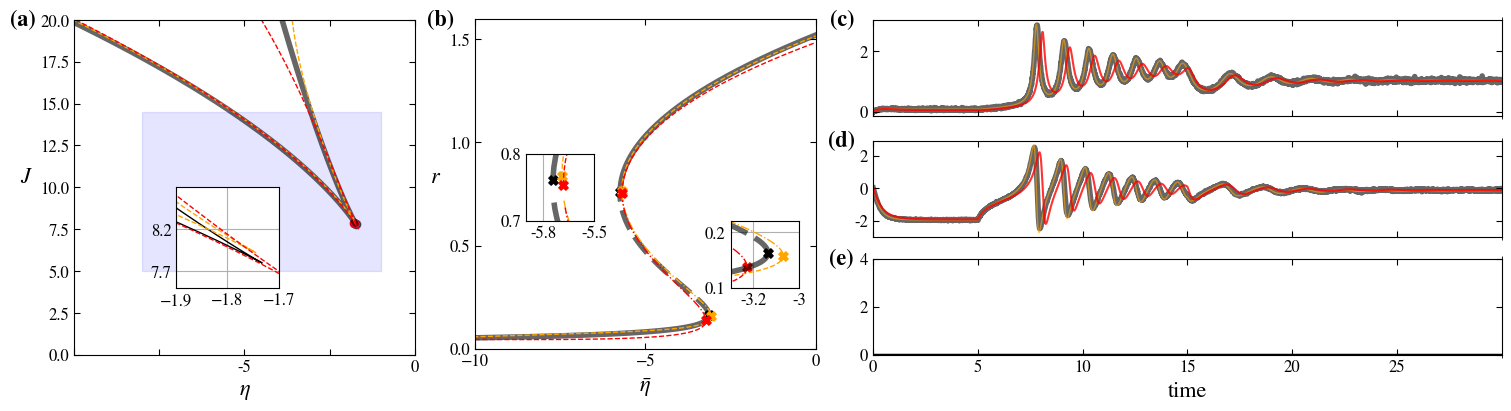

In [15]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['font.size']=16
matplotlib.rcParams['axes.labelsize']=16
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams["xtick.top"] = True
matplotlib.rcParams["ytick.right"] = True
plt.style.use('_mpl-gallery')
mdls = ['mpr', 'mlp_qif']
branches = ['', '_cusp']
titles = ['MPR', 'QIF']
fig = plt.figure(layout="constrained", figsize=(15,4))
grid = GridSpec(ncols=4, nrows=1, figure=fig)
ax1 = fig.add_subplot(grid[:,0])
ax2 = fig.add_subplot(grid[:,1])
subgrid = grid[:,2:].subgridspec(3, 1)
ax3 = fig.add_subplot(subgrid[0])
ax4 = fig.add_subplot(subgrid[1], sharex=ax3)
ax5 = fig.add_subplot(subgrid[2], sharex=ax3)
mdl = 'mpr'
title = 'MPR'

ax1.annotate('(a)', xy=(-0.15, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
ax2.annotate('(b)', xy=(-0.1, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
ax3.annotate('(c)', xy=(-0.05, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
ax4.annotate('(d)', xy=(-0.05, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
ax5.annotate('(e)', xy=(-0.05, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')



ax = ax1
df = pd.read_csv(BIFURCATION_DIR / 'mpr_cusp.csv', delimiter=',')
ax.plot(df['eta'].values, df['j'].values, c='k', linewidth=4, alpha=.6)
ax.set_xlim((-10,0))
ax.set_ylim((0,20))
ax.scatter(-1.7321412593186158, 7.796523431410675, label='MPR cusp', c='k', alpha=.6)
ax.grid(False)
ax.set_xlabel(r'$\eta$')
ax.set_xticks([-10, -5, 0])
# ax.set_yticks([0, .5, 1])
# ax.set_title(title)
ax.set_ylabel(r'$J$', rotation=0, labelpad=10)
inset_ax = ax.inset_axes([0.3, 0.2, 0.3, 0.3])
inset_ax.plot(df['eta'].values, df['j'].values, c='k', linewidth=1, alpha=1)


df = pd.read_csv(BIFURCATION_DIR / 'mlp_fre_cusp.csv', delimiter=',')
ax.plot(df['eta'].values, df['j'].values, c='orange', linestyle='--',  linewidth=1)
inset_ax.plot(df['eta'].values, df['j'].values, c='orange', linestyle='--',  linewidth=1)
df = pd.read_csv(BIFURCATION_DIR / 'mlp_qif_cusp.csv', delimiter=',')
ax.plot(df['eta'].values, df['j'].values, c='r', linestyle='--',  linewidth=1)
inset_ax.plot(df['eta'].values, df['j'].values, c='r', linestyle='--',  linewidth=1)


inset_ax.set_xlim(-1.9, -1.7)
inset_ax.set_ylim(7.5, 8.7)
# inset_ax.set_xticks([-2, -1.8], [-2, -1.8], fontsize=12)
inset_ax.set_yticks([7.7, 8.2], [7.7, 8.2])
ax.set_xlim((-10,0))
ax.set_ylim((0,20))
ax.scatter(-1.80000148925729, 7.860375749740125, label='QIF cusp', c='r')
handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles, ['MPR cusp', 'QIF cusp'], loc='lower left', borderpad=.1, handletextpad=.0, fancybox=False, frameon=False)
ax.grid(False)
ax.set_xlabel(r'$\eta$')
ax.set_xticks([-10, -7.5, -5, -2.5, 0], ['', '', -5, '', 0])
ax.tick_params(axis="y", direction='in', length=4)
ax.tick_params(axis="x", direction='in', length=4)
ax.set_ylabel(r'$J$', rotation=0, labelpad=10)

ax.set_xlim((-10,0))
ax.fill_between([-8, -1], 5, 14.5, color='blue', alpha=.1)

ax = ax2
inset_ax1 = ax.inset_axes([0.15, 0.4, 0.2, 0.2])
inset_ax2 = ax.inset_axes([0.75, 0.2, 0.2, 0.2])
df = pd.read_csv(BIFURCATION_DIR / 'mpr.csv', delimiter=',')
stable_segments = df[df['stable'] == True]
unstable_segments = df[df['stable'] == False]
if unstable_segments.shape[0] > 0:
    (cuts), = np.nonzero(np.diff(df.stable.values*1))
    cuts = np.insert(cuts, 0, 0)
    cuts = np.append(cuts, df.shape[0]-1)
    list_of_dfs = [df.iloc[cuts[n]+1:cuts[n+1]] for n in range(len(cuts)-1)]
    for i, df_i in enumerate(list_of_dfs):
        linestyle = '-' if df_i.stable.values[0] else '--'
        df_i.plot(x='eta', y='r', ax=ax, linestyle=linestyle, c='k', legend=False, linewidth=4, alpha=.6)
        df_i.plot(x='eta', y='r', ax=inset_ax1, linestyle=linestyle, c='k', legend=False, linewidth=4, alpha=.6)
        df_i.plot(x='eta', y='r', ax=inset_ax2, linestyle=linestyle, c='k', legend=False, linewidth=4, alpha=.6)
        if i>0:
            ax.scatter(df_i.iloc[0,:].eta, df_i.iloc[0,:].r, c='k', s=45, label='bp', marker='X')
            inset_ax1.scatter(df_i.iloc[0,:].eta, df_i.iloc[0,:].r, c='k', s=45, label='bp', marker='X')
            inset_ax2.scatter(df_i.iloc[0,:].eta, df_i.iloc[0,:].r, c='k', s=45, label='bp', marker='X')
        # ax.vlines(df_i.iloc[0,:].eta, -0.05, df_i.iloc[0,:].r, linestyle='--', color='r', alpha=.5)
        ax.spines.bottom.set_position(('data', 0.))
        ax.spines.top.set_position(('data', 1.5))
        ax.spines.left.set_bounds((0,1.5))
        ax.spines.right.set_bounds((0,1.5))
        # if i>0:
            # ax.text(df_i.iloc[0,:].eta+.2, -.2, f'{df_i.iloc[0,:].eta:.2f}', ha='right', va='bottom', fontsize=12, c='r') 
else:
    df.plot(x='eta', y='r', ax=ax, linestyle='-', c='k', linewidth=4, alpha=.6)
    df.plot(x='eta', y='r', ax=inset_ax1, linestyle='-', c='k', linewidth=4, alpha=.6)
    df.plot(x='eta', y='r', ax=inset_ax2, linestyle='-', c='k', linewidth=4, alpha=.6)


ax.set_xlim((-10,0))
handles, labels = ax.get_legend_handles_labels()
ax.grid(False)
ax.set_xlabel(r'$\bar{\eta}$')
ax.set_xticks([-10, -5, 0])
ax.set_yticks([0, .5, 1, 1.5])
ax.set_ylabel(r'$J$', rotation=0, labelpad=10)


df = pd.read_csv(BIFURCATION_DIR / 'mlp_fre.csv', delimiter=',')
stable_segments = df[df['stable'] == True]
unstable_segments = df[df['stable'] == False]
if unstable_segments.shape[0] > 0:
    (cuts), = np.nonzero(np.diff(df.stable.values*1))
    cuts = np.insert(cuts, 0, 0)
    cuts = np.append(cuts, df.shape[0]-1)
    list_of_dfs = [df.iloc[cuts[n]+1:cuts[n+1]] for n in range(len(cuts)-1)]
    for i, df_i in enumerate(list_of_dfs):
        linestyle = '--' if df_i.stable.values[0] else '-.'
        df_i.plot(x='eta', y='r', ax=ax, linestyle=linestyle, c='orange', legend=False, linewidth=1)
        df_i.plot(x='eta', y='r', ax=inset_ax1, linestyle=linestyle, c='orange', legend=False, linewidth=1)
        df_i.plot(x='eta', y='r', ax=inset_ax2, linestyle=linestyle, c='orange', legend=False, linewidth=1)
        if i>0:
            ax.scatter(df_i.iloc[0,:].eta, df_i.iloc[0,:].r, c='orange', s=45, label='bp', marker='X', zorder=10)
            inset_ax1.scatter(df_i.iloc[0,:].eta, df_i.iloc[0,:].r, c='orange', s=45, label='bp', marker='X')
            inset_ax2.scatter(df_i.iloc[0,:].eta, df_i.iloc[0,:].r, c='orange', s=45, label='bp', marker='X')

        # ax.vlines(df_i.iloc[0,:].eta, -0.05, df_i.iloc[0,:].r, linestyle='--', color='r', alpha=.5)
        ax.spines.bottom.set_position(('data', 0.))
        ax.spines.top.set_position(('data', 1.6))
        ax.spines.left.set_bounds((0,1.6))
        ax.spines.right.set_bounds((0,1.6))
        # if i>0:
            # ax.text(df_i.iloc[0,:].eta+.2, -.2, f'{df_i.iloc[0,:].eta:.2f}', ha='right', va='bottom', fontsize=12, c='r') 
else:
    df.plot(x='eta', y='r', ax=ax, linestyle='-', c='r',  linewidth=1)
    df.plot(x='eta', y='r', ax=inset_ax1, linestyle='-', c='r',  linewidth=1)
    df.plot(x='eta', y='r', ax=inset_ax2, linestyle='-', c='r',  linewidth=1)

df = pd.read_csv(BIFURCATION_DIR / 'mlp_qif.csv', delimiter=',')
stable_segments = df[df['stable'] == True]
unstable_segments = df[df['stable'] == False]
if unstable_segments.shape[0] > 0:
    (cuts), = np.nonzero(np.diff(df.stable.values*1))
    cuts = np.insert(cuts, 0, 0)
    cuts = np.append(cuts, df.shape[0]-1)
    list_of_dfs = [df.iloc[cuts[n]+1:cuts[n+1]] for n in range(len(cuts)-1)]
    for i, df_i in enumerate(list_of_dfs):
        linestyle = '--' if df_i.stable.values[0] else '-.'
        df_i.plot(x='eta', y='r', ax=ax, linestyle=linestyle, c='r', legend=False, linewidth=1)
        df_i.plot(x='eta', y='r', ax=inset_ax1, linestyle=linestyle, c='r', legend=False, linewidth=1)
        df_i.plot(x='eta', y='r', ax=inset_ax2, linestyle=linestyle, c='r', legend=False, linewidth=1)
        if i>0:
            ax.scatter(df_i.iloc[0,:].eta, df_i.iloc[0,:].r, c='r', s=45, label='bp', marker='X', zorder=10)
            inset_ax1.scatter(df_i.iloc[0,:].eta, df_i.iloc[0,:].r, c='r', s=45, label='bp', marker='X')
            inset_ax2.scatter(df_i.iloc[0,:].eta, df_i.iloc[0,:].r, c='r', s=45, label='bp', marker='X')

        # ax.vlines(df_i.iloc[0,:].eta, -0.05, df_i.iloc[0,:].r, linestyle='--', color='r', alpha=.5)
        ax.spines.bottom.set_position(('data', 0.))
        ax.spines.top.set_position(('data', 1.6))
        ax.spines.left.set_bounds((0,1.6))
        ax.spines.right.set_bounds((0,1.6))
        # if i>0:
            # ax.text(df_i.iloc[0,:].eta+.2, -.2, f'{df_i.iloc[0,:].eta:.2f}', ha='right', va='bottom', fontsize=12, c='r') 
else:
    df.plot(x='eta', y='r', ax=ax, linestyle='-', c='r',  linewidth=1)
    df.plot(x='eta', y='r', ax=inset_ax1, linestyle='-', c='r',  linewidth=1)
    df.plot(x='eta', y='r', ax=inset_ax2, linestyle='-', c='r',  linewidth=1)

ax.tick_params(axis="y", direction='in', length=4)
ax.tick_params(axis="x", direction='in', length=4)


ax3.plot(rslt['r'][::10], label=r'QIF $r(t)$', c='k', linewidth=4, alpha=.6)
ax3.plot(rslt['fre'][:,0], label=r'MPR $r(t)$', linewidth=1, c='orange', alpha=.6)
ax3.set_yticks([-2,0,2], [-2,0,2])
ax4.set_yticks([-2,0,2], [-2,0,2])
ax4.plot(rslt['v'][::10], label=r'QIF $v(t)$', c='k', linewidth=4, alpha=.6)
ax4.plot(rslt['fre'][:,1], label=r'MPR $v(t)$', linewidth=1, c='orange', alpha=.6)
ckpt_dir = str(TRAINED_MODELS_DIR)
orbax_checkpointer = orbax.checkpoint.PyTreeCheckpointer()
i=489
state = orbax_checkpointer.restore(ckpt_dir+f'/tmp/checkpoint_{i}')
mlp = Simple_MLP(2, [6,6], nn.tanh, scaling_factor=1, kernel_init=jax.nn.initializers.xavier_normal(), coupled=True)
mdl = NeuralOdeWrapper(2, 3, dt=.01, dfun=mlp, coupled=True)
# stim = noise_generator.
X0 = jnp.c_[jnp.zeros((30000, 2)), jnp.tile(-5, (30000,1)), jnp.tile(1., (30000,1)), jnp.tile(15., (30000,1)), stim][:,None,:]
print(X0.shape)
Y = mdl.apply({'params': state}, (X0[:,:,:5], X0[:,:,-1:]))
ax3.plot(Y[::10,0,0], label=r'MLP $r(t)$', c='r', alpha=.8)
ax4.plot(Y[::10,0,1], label=r'MLP $rv(t)$', c='r', alpha=.8)
ax3.set_xlim((0, 3000))
ax4.set_xlim((0, 3000))
ax3.set_xticks(np.arange(0,3000,500), [int(i/100) for i in np.arange(0,3000,500)], fontsize=12)
ax5.plot(rslt['I'][::10], c='k')
ax5.set_ylim((0, 4))
ax5.set_xlabel('time')

handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles[-1:], ['Bp'], loc='upper left', borderpad=.0, handletextpad=.0, fancybox=False, frameon=False)
[ax.grid(False) for ax in [ax, ax3, ax4, ax5]]
[ax.tick_params(axis="y", direction='in', length=4) for ax in [ax, ax3, ax4, ax5]]
[ax.tick_params(axis="x", direction='in', length=4) for ax in [ax, ax3, ax4, ax5]]
ax.set_xlabel(r'$\bar{\eta}$')
ax.set_xticks([-10, -5, 0])
ax.set_yticks([0, .5, 1, 1.5])
# ax.set_title(title)
ax.set_ylabel(r'$r$', rotation=0, labelpad=10)

inset_ax1.set_xlim(-5.9, -5.5)
inset_ax1.set_ylim(.7, .8)

inset_ax2.set_xlim(-3.3, -3.)
inset_ax2.set_ylim(0.12, .22)
inset_ax1.set_xticks([-5.8, -5.5], [-5.8, -5.5])
inset_ax1.set_yticks([.7, .8], [.7, .8])
inset_ax2.set_xticks([-3.2, -3.], [-3.2, -3])
inset_ax2.set_yticks([.1, .2], [.1, .2])
inset_ax1.set_xlabel(r'')
inset_ax2.set_xlabel(r'')


# plt.savefig('paper_figs/bifurcation_mpr_qif.png', facecolor="None", bbox_inches="tight", dpi=600)

0.19999999999999996
0.4
1.0
0.19999999999999996
0.4
1


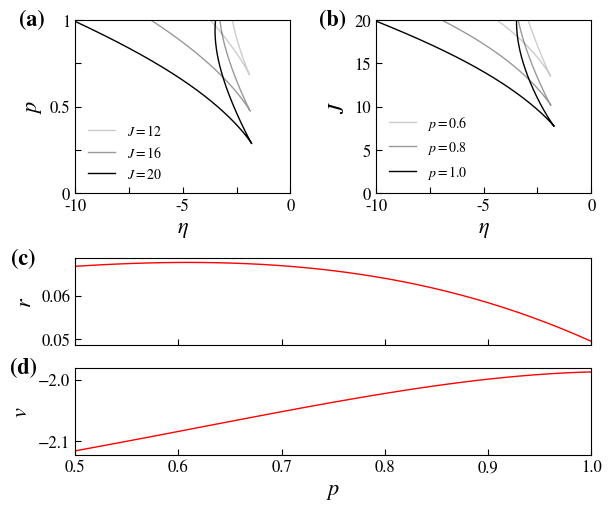

In [61]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['font.size']=16
matplotlib.rcParams['axes.labelsize']=16
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
plt.style.use('_mpl-gallery')
mdls = ['mpr', 'mlp_qif']
branches = ['', '_cusp']
titles = ['MPR', 'QIF']
fig = plt.figure(layout="constrained", figsize=(6,5))
grid = GridSpec(ncols=2, nrows=4, figure=fig)

ax1 = fig.add_subplot(grid[:2,0])
ax2 = fig.add_subplot(grid[:2,1])
ax3 = fig.add_subplot(grid[2,:])
ax4 = fig.add_subplot(grid[3,:])
mdl = 'mpr'
title = 'MPR'

ax1.annotate('(a)', xy=(-0.2, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
ax2.annotate('(b)', xy=(-0.2, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
ax3.annotate('(c)', xy=(-0.1, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')
ax4.annotate('(d)', xy=(-0.1, 1.), xycoords='axes fraction', ha='center', va='center', weight='bold')


df = pd.read_csv(BIFURCATION_DIR / 'mlp_qif_p_bifurc.csv', delimiter=',')
stable_segments = df[df['stable'] == True]
unstable_segments = df[df['stable'] == False]
if unstable_segments.shape[0] > 0:
    (cuts), = np.nonzero(np.diff(df.stable.values*1))
    cuts = np.insert(cuts, 0, 0)
    cuts = np.append(cuts, df.shape[0]-1)
    list_of_dfs = [df.iloc[cuts[n]+1:cuts[n+1]] for n in range(len(cuts)-1)]
    for i, df_i in enumerate(list_of_dfs):
        linestyle = '--' if df_i.stable.values[0] else '-.'
        df_i.plot(x='synap', y='r', ax=ax3, linestyle=linestyle, c='r', legend=False, linewidth=2)
        if i>0:
            ax3.scatter(df_i.iloc[0,:].synap, df_i.iloc[0,:].r, c='r', s=45, label='bp', marker='X', zorder=10)
        ax3.spines.bottom.set_position(('data', 0.))
        ax3.spines.top.set_position(('data', 1.6))
        ax3.spines.left.set_bounds((0,1.6))
        ax3.spines.right.set_bounds((0,1.6))

else:
    df.plot(x='eta', y='r', ax=ax3, linestyle='-', c='r',  linewidth=1, legend=False)


stable_segments = df[df['stable'] == True]
unstable_segments = df[df['stable'] == False]
if unstable_segments.shape[0] > 0:
    (cuts), = np.nonzero(np.diff(df.stable.values*1))
    cuts = np.insert(cuts, 0, 0)
    cuts = np.append(cuts, df.shape[0]-1)
    list_of_dfs = [df.iloc[cuts[n]+1:cuts[n+1]] for n in range(len(cuts)-1)]
    for i, df_i in enumerate(list_of_dfs):
        linestyle = '--' if df_i.stable.values[0] else '-.'
        df_i.plot(x='synap', y='v', ax=ax4, linestyle=linestyle, c='r', legend=False, linewidth=2)
        if i>0:
            ax4.scatter(df_i.iloc[0,:].synap, df_i.iloc[0,:].v, c='r', s=45, label='bp', marker='X', zorder=10)
        ax4.spines.bottom.set_position(('data', 0.))
        ax4.spines.top.set_position(('data', 1.6))
        ax4.spines.left.set_bounds((0,1.6))
        ax4.spines.right.set_bounds((0,1.6))

else:
    df.plot(x='eta', y='v', ax=ax4, linestyle='-', c='r',  linewidth=1, legend=False)


for j in np.arange(12, 22, 4):
    df = pd.read_csv(BIFURCATION_DIR / f'mlp_qif_cusp_p_J{int(j)}.csv', delimiter=',')
    alpha = int(j)/20-.4 if int(j) < 20 else int(j)/20
    print(alpha)
    ax1.plot(df['eta'].values, df['p'].values, linestyle='-', c='k', linewidth=1, label=rf'$J={j}$', alpha=alpha)
    ax1.set_xlim((-10,0))
    ax1.set_ylim((0,1))
ax1.legend(fontsize=10, fancybox=False, frameon=False)

p9 = (-1.8228100238439813, 8.81304130975168)
p8 = (-1.875773164176974, 10.142968065207965)
p7 = (-1.8968614859422221, 11.722957426340972)
p6 = (-1.8937835592493804, 13.519587149935083)
p1 = (-1.7272791858281866, 7.738524453096268)

for i, point in zip(['6', '8', '1'], [p6, p7, p8, p9, p1]):
    df = pd.read_csv(BIFURCATION_DIR / f'mlp_qif_cusp_p{i}.csv', delimiter=',')
    alpha = int(i)/10-.4 if int(i) > 1 else 1
    print(alpha)
    if float(i) ==1:
        ax2.plot(df['eta'].values, df['j'].values, linestyle='-', c='k', linewidth=1, label=rf'$p={i}.0$', alpha=alpha)
    else:
        ax2.plot(df['eta'].values, df['j'].values, linestyle='-', c='k', linewidth=1, label=rf'$p=0.{i}$', alpha=alpha)
    # ax2.scatter(point[0], point[1], c='r', s=15, label=f'p{i}', marker='o')
    # ax2.annotate('p', xy=(point[0]+.3, point[1]-.5), xycoords='data', ha='center', va='bottom')
    ax2.set_ylim((0,20))
    ax2.set_xlim((-10,0))
ax2.legend(fontsize=10, fancybox=False, frameon=False)

[ax.grid(False) for ax in [ax1, ax2, ax3, ax4]]
[ax.tick_params(axis="y", direction='in', length=4) for ax in [ax1, ax2, ax3, ax4]]
[ax.tick_params(axis="x", direction='in', length=4) for ax in [ax1, ax2, ax3, ax4]]
ax3.set_xlabel("")
ax3.set_xlim((0.5, 1.))
ax4.set_xlim((0.5, 1.))
ax3.set_xticklabels([])
ax4.set_xlabel(r'$p$')
ax3.set_ylabel(r'$r$')
ax4.set_ylabel(r'$v$')
ax1.set_xlabel(r'$\eta$')
ax1.set_ylabel(r'$p$')
ax2.set_xlabel(r'$\eta$')
ax2.set_ylabel(r'$J$')
ax1.set_xticks([-10, -7.5, -5, -2.5, 0], [-10, '', -5, '', 0])
ax1.set_yticks([0, .25, .5, .75, 1], [0, "", 0.5,"", 1])
ax2.set_xticks([-10, -7.5, -5, -2.5, 0], [-10, '', -5, '', 0])

plt.savefig('paper_figs/p_cusp.png', facecolor="None", bbox_inches="tight", dpi=600)
